# Traffic Accident Severity Prediction
**Pipeline:** Data Loading → Feature Engineering → Preprocessing → Feature Selection → Modeling (Logistic Regression + SVM) → Evaluation

---

In [18]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, recall_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded.')

All libraries loaded.


## 1. Data Loading & Feature Engineering

In [19]:
# ============================================================
# Cell 2 — Load the cleaned dataset
# ============================================================
df = pd.read_csv('dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (12316, 16)


,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity,speed
0,18-30,Male,Above high school,Employee,1-2yr,Unknown,No junction,Asphalt roads,Daylight,Normal,Collision with roadside-parked vehicles,Going straight,Not a Pedestrian,Moving Backward,2,69
1,31-50,Male,Junior high school,Employee,Above 10yr,Undivided Two way,No junction,Asphalt roads,Daylight,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2,93
2,18-30,Male,Junior high school,Employee,1-2yr,other,No junction,Asphalt roads,Daylight,Normal,Collision with roadside objects,Going straight,Not a Pedestrian,Changing lane to the left,1,46
3,18-30,Male,Junior high school,Employee,5-10yr,other,Y Shape,Earth roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Changing lane to the right,2,30
4,18-30,Male,Junior high school,Employee,2-5yr,other,Y Shape,Asphalt roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2,84


In [20]:
'''
# ============================================================
# Cell 3 — Generate synthetic 'speed' column
# ============================================================
# ASSUMPTIONS:
# - Speed depends on the road surface and the vehicle movement.
# - Base speeds (km/h) vary by vehicle movement pattern:
#     Going straight → 40-120 km/h (highway-like)
#     Reversing / Moving Backward → 5-20 km/h
#     Entering a junction / U-Turn → 10-35 km/h
#     Stopping / Parked / Waiting → 0-10 km/h
#     Others → 20-70 km/h
# - Hazardous road surfaces (Earth, Gravel, Distress) reduce speed
#   by ~20% on average via a multiplier of 0.6-1.0.
# - A small amount of Gaussian noise is added for realism.

np.random.seed(42)  # reproducibility

# Base speed ranges by vehicle movement
movement_speed = {
    'Going straight':        (40, 120),
    'Overtaking':            (60, 130),
    'Moving Backward':       (5,  20),
    'Reversing':             (5,  20),
    'Entering a junction':   (10, 35),
    'U-Turn':                (10, 35),
    'Turnover':              (30, 90),
    'Getting off':           (0,  15),
    'Stopping':              (0,  10),
    'Parked':                (0,  5),
    'Waiting to go':         (0,  10),
}
default_range = (20, 70)

# Road surface multiplier (hazardous surfaces → lower speed)
road_multiplier = {
    'Asphalt roads':                    (0.85, 1.0),
    'Asphalt roads with some distress': (0.65, 0.85),
    'Gravel roads':                     (0.55, 0.75),
    'Earth roads':                      (0.50, 0.70),
}
default_mult = (0.60, 1.0)


def generate_speed(row):
    lo, hi = movement_speed.get(row['Vehicle_movement'], default_range)
    base = np.random.uniform(lo, hi)
    m_lo, m_hi = road_multiplier.get(row['Road_surface_type'], default_mult)
    mult = np.random.uniform(m_lo, m_hi)
    speed = base * mult
    return max(0, round(speed))  # no negative speeds


df['speed'] = df.apply(generate_speed, axis=1)
print('speed column created.')
print(df['speed'].describe())
df[['Vehicle_movement', 'Road_surface_type', 'speed']].head(10)

'''

"\n# ============================================================\n# Cell 3 — Generate synthetic 'speed' column\n# ============================================================\n# ASSUMPTIONS:\n# - Speed depends on the road surface and the vehicle movement.\n# - Base speeds (km/h) vary by vehicle movement pattern:\n#     Going straight → 40-120 km/h (highway-like)\n#     Reversing / Moving Backward → 5-20 km/h\n#     Entering a junction / U-Turn → 10-35 km/h\n#     Stopping / Parked / Waiting → 0-10 km/h\n#     Others → 20-70 km/h\n# - Hazardous road surfaces (Earth, Gravel, Distress) reduce speed\n#   by ~20% on average via a multiplier of 0.6-1.0.\n# - A small amount of Gaussian noise is added for realism.\n\nnp.random.seed(42)  # reproducibility\n\n# Base speed ranges by vehicle movement\nmovement_speed = {\n    'Going straight':        (40, 120),\n    'Overtaking':            (60, 130),\n    'Moving Backward':       (5,  20),\n    'Reversing':             (5,  20),\n    'Entering a 

## 2. Data Preprocessing & Cleaning

In [21]:
# ============================================================
# Cell 4 — Inspect missing values and data types
# ============================================================
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal rows before cleaning: {len(df)}')

Missing values per column:
Age_band_of_driver         0
Sex_of_driver              0
Educational_level          0
Vehicle_driver_relation    0
Driving_experience         0
Lanes_or_Medians           0
Types_of_Junction          0
Road_surface_type          0
Light_conditions           0
Weather_conditions         0
Type_of_collision          0
Vehicle_movement           0
Pedestrian_movement        0
Cause_of_accident          0
Accident_severity          0
speed                      0
dtype: int64

Total rows before cleaning: 12316


In [22]:
# ============================================================
# Cell 5 — Handle missing values & remove irrelevant records
# ============================================================
# Fill missing categorical values with the column mode.
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Drop rows where the target itself is missing (if any).
df.dropna(subset=['Accident_severity'], inplace=True)

# Remove rows tagged "Unknown" / "Other" in key columns — these add
# noise rather than signal when the model tries to learn real patterns.
noise_cols = ['Weather_conditions', 'Road_surface_type',
              'Vehicle_movement', 'Lanes_or_Medians']
for col in noise_cols:
    df = df[~df[col].isin(['Unknown', 'Other'])]

df.reset_index(drop=True, inplace=True)
print(f'Rows after cleaning: {len(df)}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Rows after cleaning: 9804
Missing values remaining: 0


In [23]:
# ============================================================
# Cell 6 — Encode categorical variables & scale features
# ============================================================
# Map the original column names to short, consistent names:
#   Weather_conditions  → weather
#   Road_surface_type   → road_condition
#   Vehicle_movement    → vehicle_type
#   Driving_experience  → driving_exp
#   Types_of_Junction   → junction_type
#   Light_conditions    → light_cond
#   speed               → speed          (already named)

df.rename(columns={
    'Weather_conditions': 'weather',
    'Road_surface_type':  'road_condition',
    'Vehicle_movement':   'vehicle_type',
    'Driving_experience': 'driving_exp',
    'Types_of_Junction':  'junction_type',
    'Light_conditions':   'light_cond',
}, inplace=True)

# Label-encode the target (Accident_severity: 0, 1, 2)
# The values are already integers (0 / 1 / 2) stored as int64.
df['Accident_severity'] = df['Accident_severity'].astype(int)

print('Columns after renaming:')
print(df.columns.tolist())

Columns after renaming:
['Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'driving_exp', 'Lanes_or_Medians', 'junction_type', 'road_condition', 'light_cond', 'weather', 'Type_of_collision', 'vehicle_type', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity', 'speed']


## 3. Feature Selection

In [24]:
# ============================================================
# Cell 7 — Select the most impactful features
# ============================================================
# Retain key predictors that capture vehicle kinetics, driver
# profile, environmental hazard, road surface quality, and
# junction geometry — the primary factors influencing severity.

selected_features = [
    'speed', 'weather', 'road_condition', 'vehicle_type',
    'driving_exp', 'junction_type', 'light_cond',
]
target = 'Accident_severity'

X = df[selected_features].copy()
y = df[target].copy()

print(f'Features: {selected_features}')
print(f'Target classes: {sorted(y.unique())}')
print(f'\nTarget distribution:\n{y.value_counts().sort_index()}')

Features: ['speed', 'weather', 'road_condition', 'vehicle_type', 'driving_exp', 'junction_type', 'light_cond']
Target classes: [np.int64(0), np.int64(1), np.int64(2)]

Target distribution:
Accident_severity
0     134
1    1390
2    8280
Name: count, dtype: int64


In [25]:
# ============================================================
# Cell 8 — One-Hot Encode categorical features
# ============================================================
cat_cols = ['weather', 'road_condition', 'vehicle_type',
            'driving_exp', 'junction_type', 'light_cond']
X = pd.get_dummies(X, columns=cat_cols)
print(f'Feature matrix shape after encoding: {X.shape}')
X.head()

Feature matrix shape after encoding: (9804, 43)


,speed,weather_Cloudy,weather_Fog or mist,weather_Normal,weather_Raining,weather_Raining and Windy,weather_Snow,weather_Windy,road_condition_Asphalt roads,road_condition_Asphalt roads with some distress,...,junction_type_O Shape,junction_type_Other,junction_type_T Shape,junction_type_Unknown,junction_type_X Shape,junction_type_Y Shape,light_cond_Darkness - lights lit,light_cond_Darkness - lights unlit,light_cond_Darkness - no lighting,light_cond_Daylight
0,93,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,46,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
2,30,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,84,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
4,13,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True


## 4. Modeling

In [26]:
# ============================================================
# Cell 9 — Train / Test split + Feature Scaling
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler is essential for SVM — it centres features to
# zero mean and unit variance so that no single feature dominates
# the kernel distance computation.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train_sc.shape[0]}  |  Test size: {X_test_sc.shape[0]}')

Train size: 7843  |  Test size: 1961


In [27]:
# ============================================================
# Cell 10 — Train Logistic Regression
# ============================================================
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_sc, y_train)
y_pred_log = log_model.predict(X_test_sc)
print('Logistic Regression trained.')

Logistic Regression trained.


In [28]:
# ============================================================
# Cell 11 — Train SVM with Linear kernel
# ============================================================
# Linear kernel: finds a straight hyperplane that separates classes.
# Works well when the data is (roughly) linearly separable.
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_sc, y_train)
y_pred_linear = svm_linear.predict(X_test_sc)
print('SVM Linear trained.')

SVM Linear trained.


In [29]:
# ============================================================
# Cell 12 — Train SVM with Polynomial kernel
# ============================================================
# Polynomial kernel (degree=3): maps features into a higher-
# dimensional space to capture curved decision boundaries.
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_sc, y_train)
y_pred_poly = svm_poly.predict(X_test_sc)
print('SVM Polynomial trained.')

SVM Polynomial trained.


In [30]:
# ============================================================
# Cell 13 — Train SVM with RBF kernel
# ============================================================
# RBF (Radial Basis Function) kernel: can model complex, non-linear
# patterns by measuring similarity in an infinite-dimensional space.
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_sc, y_train)
y_pred_rbf = svm_rbf.predict(X_test_sc)
print('SVM RBF trained.')

SVM RBF trained.


## 5. Evaluation

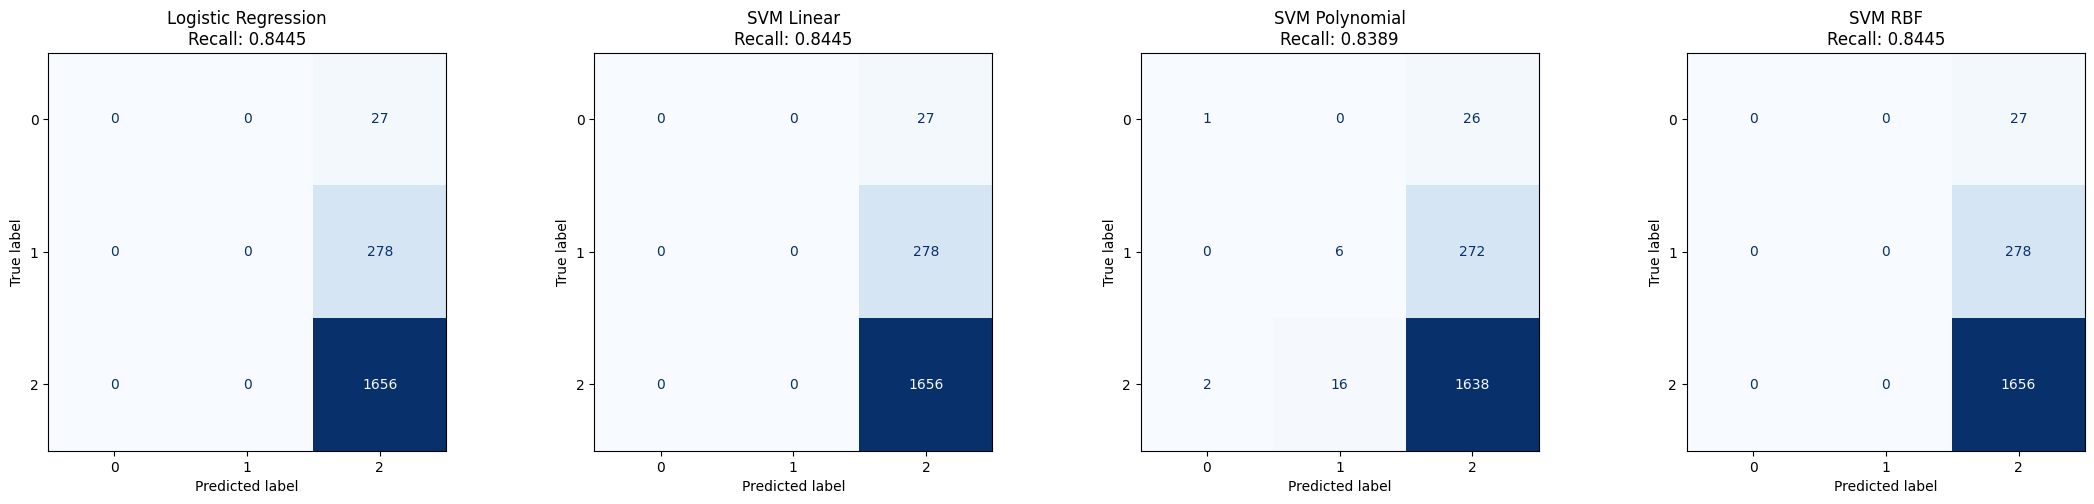

In [31]:
# ============================================================
# Cell 14 — Confusion Matrices + Recall Scores
# ============================================================
models = {
    'Logistic Regression': y_pred_log,
    'SVM Linear':          y_pred_linear,
    'SVM Polynomial':      y_pred_poly,
    'SVM RBF':             y_pred_rbf,
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
recall_results = {}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    recall_results[name] = recall

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nRecall: {recall:.4f}')

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Cell 15 — Recall comparison summary
# ============================================================
print(f'{"Model":<25} {"Recall (weighted)":>18}')
print('-' * 44)
for name, recall in recall_results.items():
    print(f'{name:<25} {recall:>18.4f}')

best = max(recall_results, key=recall_results.get)
print(f'\nBest model by recall: {best} ({recall_results[best]:.4f})')

Model                      Recall (weighted)
--------------------------------------------
Logistic Regression                   0.8445
SVM Linear                            0.8445
SVM Polynomial                        0.8389
SVM RBF                               0.8445

Best model by recall: Logistic Regression (0.8445)
